# OLS Regression on the Ames Housing Data -- A Teaching Notebook

This notebook is **not** trying to produce a good Kaggle score. It fits the same
linear regression five times, adding one small group of variables at each step,
so that each core idea in OLS regression shows up on its own, in isolation, in
the output:

1. A single raw coefficient (Model 1)
2. An elasticity, and coefficients shifting when a confounder is controlled for (Model 2)
3. One-hot encoding of a categorical variable and what "baseline level" means (Model 3)
4. Multicollinearity -- what it looks like when two predictors carry the same information (Model 4)
5. The fix, and adjusted R² penalizing a variable that doesn't pull its weight (Model 5)

We use `statsmodels` (via its formula API, `smf.ols`) instead of `scikit-learn`
specifically because we want the full `.summary()` table -- coefficients,
standard errors, t-statistics, p-values, R² -- not just predictions. Reading
that table correctly is the actual skill this notebook is building.

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

## Why we model `log(SalePrice)`, not `SalePrice`

Before touching any predictor, one choice matters more than the rest: we will
regress `np.log(SalePrice)`, not raw `SalePrice`. Four separate reasons, all
pointing the same way:

- **Right-skew.** House prices have a long right tail -- a handful of very
  expensive homes stretch the distribution out. Logging compresses that tail
  and makes the target much closer to a symmetric, "normal-ish" shape, which is
  what OLS's inference machinery (standard errors, p-values) assumes about the
  residuals.
- **Effects are naturally multiplicative, not additive.** An extra bathroom
  probably raises a house's price by roughly the same *percentage* whether the
  house is worth \$100k or \$500k -- not by the same *dollar amount*. A model
  on the raw price forces every effect to be a flat dollar amount; a model on
  the log price lets every coefficient be read as a percentage effect instead,
  which matches how these effects actually behave.
- **Equal percentage errors become equal errors.** Being off by \$20k on a
  \$100k house is a much bigger mistake than being off by \$20k on a \$1M
  house. On the log scale, a fixed *error in log-price* corresponds to a fixed
  *percentage* error regardless of price level -- so OLS's assumption of
  constant residual variance ("homoskedasticity") is far more plausible in log
  space than in raw dollars.
- **It matches the competition's own metric.** The Kaggle scoring metric here
  is RMSE between `log(predicted)` and `log(actual)` -- so modelling in log
  space from the start optimizes the thing that's actually being measured,
  instead of optimizing raw-dollar error and hoping it transfers.

We'll also log `GrLivArea` (living area) for the same "multiplicative effect"
reason -- floor space almost certainly matters in percentage terms too (going
from 1000 to 1100 sqft probably matters more than going from 4000 to 4100).

First, a quick visual check that the skew claim is actually true here.

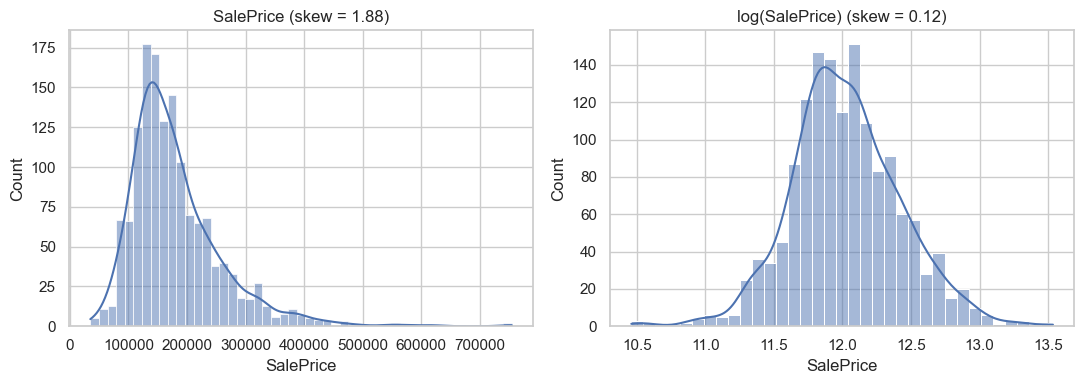

In [5]:
raw = pd.read_csv('../inputs/train.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(raw['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice (skew = {skew(raw['SalePrice']):.2f})")

sns.histplot(np.log(raw['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title(f"log(SalePrice) (skew = {skew(np.log(raw['SalePrice'])):.2f})")
plt.tight_layout()

Skew near 0 means roughly symmetric. Raw `SalePrice` is well above 0 (a long
right tail); `log(SalePrice)` is much closer to symmetric. That's the
distributional case for logging made concrete.

## Picking the variables, and checking for missing values

This notebook deliberately ignores 74 of the 79 available features. We use
exactly five predictors, added in groups:

- `OverallQual` -- an overall quality rating, 1 (worst) to 10 (best)
- `GrLivArea` -- above-ground living area in square feet (used as `np.log(GrLivArea)`)
- `Neighborhood` -- which of 25 physical locations in Ames the house is in
- `GarageCars` -- garage capacity, in cars
- `GarageArea` -- garage size, in square feet

Fewer variables means every change in the `.summary()` output between models
can be attributed to something we did on purpose, rather than getting lost
among dozens of simultaneous changes.

Before fitting anything, we check these five columns (plus the target) for
missing values. Any numeric column with missing values would get filled with
its median -- a simple, defensible default that doesn't require a modelling
decision at this stage -- and that choice would be reported here rather than
applied silently.

In [6]:
cols = ['OverallQual', 'GrLivArea', 'Neighborhood', 'GarageCars', 'GarageArea', 'SalePrice']
train = raw[cols].copy()

missing = train.isna().sum()
print('Missing values per column:')
print(missing)

numeric_cols = train.select_dtypes(include=[np.number]).columns
for c in numeric_cols:
    n_missing = train[c].isna().sum()
    if n_missing > 0:
        median_val = train[c].median()
        train[c] = train[c].fillna(median_val)
        print(f'Filled {n_missing} missing values in {c} with the median ({median_val}).')

train.head()

Missing values per column:
OverallQual     0
GrLivArea       0
Neighborhood    0
GarageCars      0
GarageArea      0
SalePrice       0
dtype: int64


,OverallQual,GrLivArea,Neighborhood,GarageCars,GarageArea,SalePrice
0,7,1710,CollgCr,2,548,208500
1,6,1262,Veenker,2,460,181500
2,7,1786,CollgCr,2,608,223500
3,7,1717,Crawfor,3,642,140000
4,8,2198,NoRidge,3,836,250000


As it turns out, all five columns have **zero** missing values in `train.csv`
-- the fill-with-median code above ran and found nothing to do. That's worth
confirming rather than assuming: `GarageCars`/`GarageArea` are `0` (not `NaN`)
for houses with no garage, which is a data-entry choice specific to this
dataset, not something you should expect to hold in general.

## Model 1: `log(SalePrice) ~ OverallQual`

The simplest possible model: one predictor, one intercept, nothing else. This
is our baseline for everything that follows -- watch how its `OverallQual`
coefficient changes (or doesn't) as later models add controls.

What to look for in the `.summary()` output below:
- The **sign** of the `OverallQual` coefficient (should be positive -- higher
  quality, higher price).
- Its **magnitude** -- since the left-hand side is `log(SalePrice)`, this
  coefficient is (approximately) a percentage effect per quality point, not a
  dollar effect.
- **R²** -- how much of the variance in `log(SalePrice)` a single 1-10 quality
  rating explains, with no other information at all.

In [7]:
model1 = smf.ols('np.log(SalePrice) ~ OverallQual', data=train).fit()
print(model1.summary())
print(f"\nR-squared:          {model1.rsquared:.4f}")
print(f"Adjusted R-squared:  {model1.rsquared_adj:.4f}")

coef = model1.params['OverallQual']
pct_effect = (np.exp(coef) - 1) * 100
print(f"\nOverallQual coefficient: {coef:.4f}")
print(f"Implied effect per quality point: {pct_effect:.1f}% higher SalePrice")

                            OLS Regression Results                            
Dep. Variable:      np.log(SalePrice)   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     2931.
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:01:30   Log-Likelihood:                 73.088
No. Observations:                1460   AIC:                            -142.2
Df Residuals:                    1458   BIC:                            -131.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      10.5844      0.027    388.183      

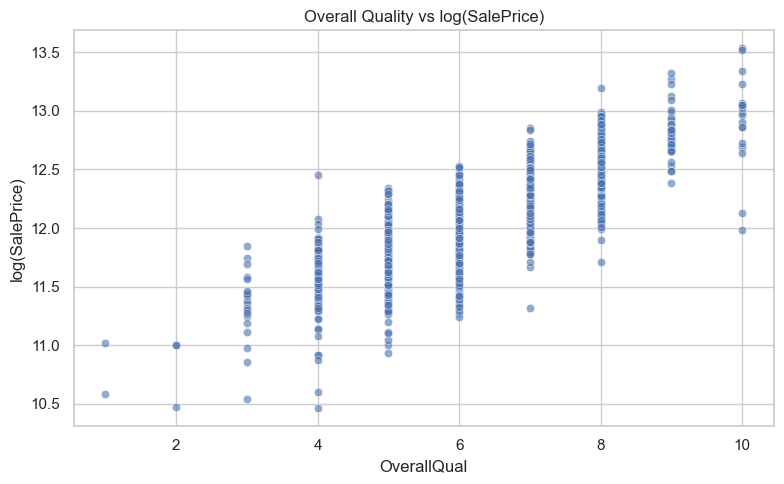

In [8]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.scatterplot(data=train, x='OverallQual', y=np.log(train['SalePrice']), alpha=0.6, ax=ax)
ax.set_title('Overall Quality vs log(SalePrice)')
ax.set_xlabel('OverallQual')
ax.set_ylabel('log(SalePrice)')
plt.tight_layout()

**Reading it:** the coefficient is about **0.236**, positive as expected. On
the log scale, a coefficient isn't itself a percentage -- to get the exact
percentage effect you exponentiate: `(exp(0.236) - 1) * 100 ≈ 26.6%`. So each
extra point of `OverallQual` is associated with roughly **27% higher
SalePrice**, on average, with nothing else held constant (and nothing else
*can* be held constant yet -- this model doesn't know about size, location, or
anything else).

That "nothing else held constant" caveat matters: `OverallQual` alone explains
about **67%** of the variance in `log(SalePrice)` (R² ≈ 0.668), which is a lot
for one variable -- but a chunk of that is quality standing in for things it's
correlated with, like house size. The next model starts to pull that apart.

## Model 2: add `log(GrLivArea)`

Now we add living area, in logs. Two things to watch for:

- Because **both** sides of the equation are logged, `log(GrLivArea)`'s
  coefficient is an **elasticity**: the percentage change in `SalePrice` for a
  1% change in `GrLivArea`. This is a different, cleaner interpretation than
  Model 1's "log-linear" coefficient, which was a percentage effect per *unit*
  (one quality point), not per *percent*.
- Watch the `OverallQual` coefficient. If it moves, that tells you Model 1's
  estimate was partly capturing size, not pure quality -- a textbook case of an
  **omitted variable** biasing a coefficient until you add the variable it was
  standing in for.

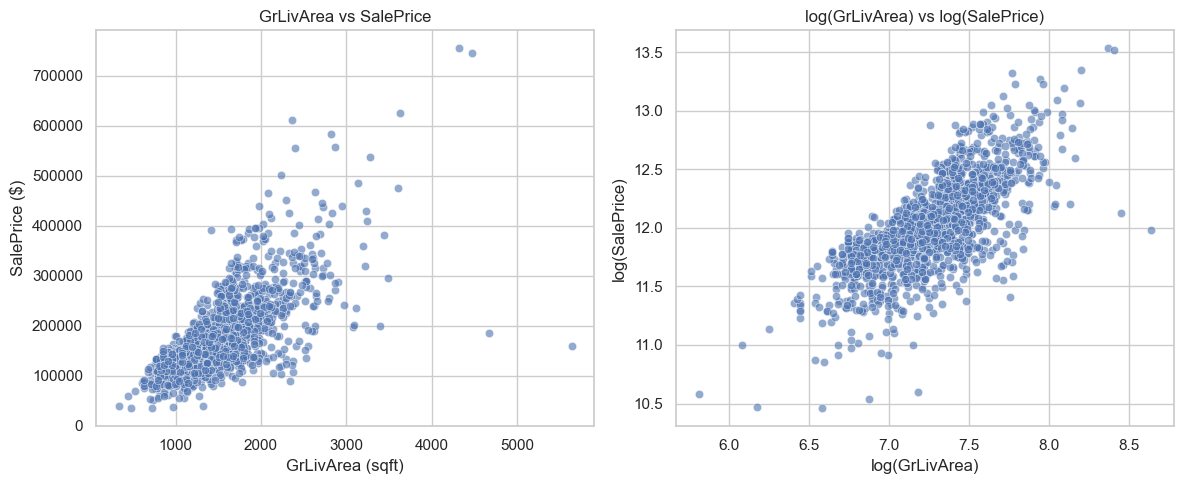

In [10]:
fig2, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', ax=axs[0], alpha=0.6)
axs[0].set_title('GrLivArea vs SalePrice')
axs[0].set_xlabel('GrLivArea (sqft)')
axs[0].set_ylabel('SalePrice ($)')

sns.scatterplot(x=np.log(train['GrLivArea']), y=np.log(train['SalePrice']), ax=axs[1], alpha=0.6)
axs[1].set_title('log(GrLivArea) vs log(SalePrice)')
axs[1].set_xlabel('log(GrLivArea)')
axs[1].set_ylabel('log(SalePrice)')

plt.tight_layout()
plt.show()

In [9]:
model2 = smf.ols('np.log(SalePrice) ~ OverallQual + np.log(GrLivArea)', data=train).fit()
print(model2.summary())
print(f"\nR-squared:          {model2.rsquared:.4f}")
print(f"Adjusted R-squared:  {model2.rsquared_adj:.4f}")

shift = model2.params['OverallQual'] - model1.params['OverallQual']
print(f"\nOverallQual coefficient: {model1.params['OverallQual']:.4f} (Model 1) -> {model2.params['OverallQual']:.4f} (Model 2)")
print(f"Shift: {shift:+.4f}")
print(f"log(GrLivArea) coefficient (elasticity): {model2.params['np.log(GrLivArea)']:.4f}")

                            OLS Regression Results                            
Dep. Variable:      np.log(SalePrice)   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     2203.
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:08:54   Log-Likelihood:                 285.05
No. Observations:                1460   AIC:                            -564.1
Df Residuals:                    1457   BIC:                            -548.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.7899      0.12

**Reading it:** `log(GrLivArea)`'s coefficient is about **0.439** -- a 1%
increase in living area is associated with roughly a 0.44% increase in
SalePrice. That's the elasticity interpretation, and it only works this
cleanly because *both* variables are logged.

`OverallQual`'s coefficient **dropped from 0.236 to 0.171** -- about a 27%
relative decrease. This is exactly the omitted-variable story: bigger houses
tend to also be rated higher quality, so in Model 1, `OverallQual` was
partly absorbing the effect of a variable (size) that wasn't in the model yet.
Once size is controlled for directly, quality's *own* effect -- net of size --
shrinks to something closer to the truth. R² rose from 0.668 to **0.752**:
size adds real, distinct information beyond quality.

## Model 3: add `Neighborhood`

`Neighborhood` is categorical (25 distinct locations), so it can't enter the
formula as a single numeric variable -- `C(Neighborhood)` tells the formula
API to one-hot encode it: create one 0/1 dummy column per category, and drop
one category to serve as the reference level (keeping all 25 would be
redundant -- see the note on the "dummy variable trap" below the output).

What to look for:
- How many new coefficients appear (one per category, minus the one dropped).
- The dropped **baseline** category -- every other neighborhood's coefficient
  is read *relative to it*, not as a standalone effect.
- Whether `OverallQual` and `log(GrLivArea)`'s coefficients move again now
  that location is controlled for.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=train, x='OverallQual', y='SalePrice', alpha=0.6, ax=ax)
ax.set_title('Overall Quality vs SalePrice')
ax.set_xlabel('OverallQual')
ax.set_ylabel('SalePrice ($)')
plt.tight_layout()

In [6]:
model3 = smf.ols('np.log(SalePrice) ~ OverallQual + np.log(GrLivArea) + C(Neighborhood)', data=train).fit()
print(model3.summary())
print(f"\nR-squared:          {model3.rsquared:.4f}")
print(f"Adjusted R-squared:  {model3.rsquared_adj:.4f}")

neigh_params = [p for p in model3.params.index if p.startswith('C(Neighborhood)')]
all_neighborhoods = set(train['Neighborhood'].unique())
included_neighborhoods = {p.split('[T.')[1].rstrip(']') for p in neigh_params}
baseline_neighborhood = (all_neighborhoods - included_neighborhoods).pop()

print(f"\n{train['Neighborhood'].nunique()} unique neighborhoods -> {len(neigh_params)} dummy columns")
print(f"Baseline (dropped) neighborhood: {baseline_neighborhood}")
print("\nNeighborhood coefficients, sorted (relative to baseline):")
print(model3.params[neigh_params].sort_values())

print(f"\nOverallQual coefficient:      {model2.params['OverallQual']:.4f} (Model 2) -> {model3.params['OverallQual']:.4f} (Model 3)")
print(f"log(GrLivArea) coefficient:   {model2.params['np.log(GrLivArea)']:.4f} (Model 2) -> {model3.params['np.log(GrLivArea)']:.4f} (Model 3)")

                            OLS Regression Results                            
Dep. Variable:      np.log(SalePrice)   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     263.9
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:24:13   Log-Likelihood:                 550.29
No. Observations:                1460   AIC:                            -1047.
Df Residuals:                    1433   BIC:                            -903.9
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

**Reading it:** 25 neighborhoods became **24 dummy columns**. The dropped
baseline is **`Blmngtn`** (Bloomington Heights) -- `C()` drops the
alphabetically-first category by default when the formula also has an
intercept. That's not a modelling choice about which neighborhood is
"typical"; it's just an implementation default, which is exactly why it's
worth checking rather than assuming.

Every neighborhood coefficient is read as: *"log-price is this much higher or
lower than a `Blmngtn` house with the same quality and size."* The extremes:
`BrDale` at about **-0.35** (`exp(-0.35) - 1 ≈ -30%` vs. baseline) and
`NridgHt` at about **+0.21** (`exp(0.21) - 1 ≈ +23%` vs. baseline) -- a roughly
50-percentage-point spread in price between the cheapest and priciest
neighborhoods, holding quality and size fixed.

`OverallQual`'s coefficient fell again, from 0.171 to about **0.115** --
quality is *also* partly proxying for neighborhood (nicer areas tend to have
higher-quality homes). `log(GrLivArea)`'s elasticity barely moved (0.439 ->
0.434) -- the size effect looks fairly independent of location. R² rose to
**0.827**: location adds a lot on top of quality and size.

*A note on the "dummy variable trap":* if all 25 dummies were kept alongside
an intercept, the columns would sum to exactly 1 for every row (the intercept
column), making the design matrix singular -- OLS couldn't uniquely solve for
the coefficients. Dropping one category avoids that; the dropped category's
effect is absorbed into the intercept instead.

## Model 4: add `GarageCars` AND `GarageArea` together

This one is deliberate, not an oversight: `GarageCars` (capacity) and
`GarageArea` (square feet) measure almost the same underlying thing -- a
bigger garage holds more cars. Adding both at once is how you *see*
multicollinearity happen, rather than just being told about it.

What to look for: compare each variable's coefficient and standard error here
against what they'd look like fit **alone** (computed below for comparison).
Classic symptoms of multicollinearity are inflated standard errors, unstable
coefficients that shrink once the correlated partner is added, and
occasionally a sign flip -- though as you'll see, a flip isn't guaranteed;
the shrink-and-inflate pattern is the more common and more subtle tell.

In [7]:
model4 = smf.ols(
    'np.log(SalePrice) ~ OverallQual + np.log(GrLivArea) + C(Neighborhood) + GarageCars + GarageArea',
    data=train,
).fit()
print(model4.summary())
print(f"\nR-squared:          {model4.rsquared:.4f}")
print(f"Adjusted R-squared:  {model4.rsquared_adj:.4f}")

# Fit each garage variable ALONE (with the same other controls) for comparison
model_cars_alone = smf.ols(
    'np.log(SalePrice) ~ OverallQual + np.log(GrLivArea) + C(Neighborhood) + GarageCars',
    data=train,
).fit()
model_area_alone = smf.ols(
    'np.log(SalePrice) ~ OverallQual + np.log(GrLivArea) + C(Neighborhood) + GarageArea',
    data=train,
).fit()

print(f"\nCorrelation between GarageCars and GarageArea: {train['GarageCars'].corr(train['GarageArea']):.3f}")

print("\nGarageCars  -- coefficient (std err):")
print(f"  alone:            {model_cars_alone.params['GarageCars']:.4f}  ({model_cars_alone.bse['GarageCars']:.4f})")
print(f"  with GarageArea:  {model4.params['GarageCars']:.4f}  ({model4.bse['GarageCars']:.4f})")

print("\nGarageArea  -- coefficient (std err):")
print(f"  alone:            {model_area_alone.params['GarageArea']:.6f}  ({model_area_alone.bse['GarageArea']:.6f})")
print(f"  with GarageCars:  {model4.params['GarageArea']:.6f}  ({model4.bse['GarageArea']:.6f})")

                            OLS Regression Results                            
Dep. Variable:      np.log(SalePrice)   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     272.1
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:24:13   Log-Likelihood:                 615.11
No. Observations:                1460   AIC:                            -1172.
Df Residuals:                    1431   BIC:                            -1019.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

**Reading it:** `GarageCars` and `GarageArea` are correlated at **0.88** --
about as collinear as two "different" variables get in practice. The effect
on the fit:

- `GarageCars` alone: coefficient **0.084** (se 0.0078). With `GarageArea`
  also in the model: coefficient **0.041** (se 0.0133) -- it *roughly halves*,
  and its standard error grows by ~70%.
- `GarageArea` alone: coefficient **0.000289** (se 0.000026). With
  `GarageCars` also in the model: coefficient **0.000177** (se 0.000045) --
  again shrinks by nearly 40%, with the standard error roughly doubling.

Neither coefficient flips sign here, and both are still nominally
"significant" by their p-values -- which is itself the lesson: **multicollinearity
doesn't have to produce a dramatic, obviously-broken result to be a real
problem.** The subtler, more common symptom is exactly what happened above --
each variable's *individual* coefficient becomes smaller and noisier once you
add a variable that's carrying almost the same information, even though the
model's overall fit (R² = 0.842) is fine. You can no longer trust either
coefficient alone to tell you "the effect of garage capacity" or "the effect
of garage size" in isolation -- the model can't tell which of the two
correlated variables deserves the credit, so it splits it between them
unstably.

### Formal diagnostic: Variance Inflation Factor (VIF)

VIF puts a number on exactly that instability. For each predictor, VIF
measures how much its coefficient's variance is inflated because it can be
predicted from the *other* predictors. VIF near **1** means a variable is
essentially uncorrelated with the rest; above roughly **5** is a common rule
of thumb for "this is redundant enough to worry about."

We compute VIF for the four numeric predictors only (`OverallQual`,
`log(GrLivArea)`, `GarageCars`, `GarageArea`), skipping the 24 `Neighborhood`
dummy columns. Dummies from a single categorical variable are *mechanically*
correlated with each other by construction (knowing 24 of them tells you the
25th), which would show up as elevated VIF for a completely different reason
than the garage story we're illustrating -- so we leave them out to keep this
diagnostic focused on the multicollinearity we actually introduced on purpose.

In [8]:
vif_data = pd.DataFrame({
    'OverallQual': train['OverallQual'],
    'log_GrLivArea': np.log(train['GrLivArea']),
    'GarageCars': train['GarageCars'],
    'GarageArea': train['GarageArea'],
})
X = sm.add_constant(vif_data)

vif_table = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif_table = vif_table[vif_table['variable'] != 'const'].reset_index(drop=True)
vif_table

,variable,VIF
0,OverallQual,1.978551
1,log_GrLivArea,1.680321
2,GarageCars,4.893873
3,GarageArea,4.570577


**Reading it:** `OverallQual` (~1.98) and `log(GrLivArea)` (~1.68) sit well
below the ~5 flag -- some correlation with the rest of the model, nothing
concerning. `GarageCars` (~4.89) and `GarageArea` (~4.57) sit right at the
threshold -- exactly the two variables the coefficient comparison above
already showed behaving unstably. VIF didn't tell us anything the coefficient
shift and inflated standard errors hadn't already hinted at -- but it turns
"these two look shaky" into a specific number you can check without having to
fit extra one-at-a-time models every time.

## Model 5: drop `GarageArea`, keep only `GarageCars`

The fix for two variables carrying the same information usually isn't a
statistical trick -- it's deciding which one to keep. `GarageCars` is easier to
interpret (a whole-number capacity) and was the slightly stronger predictor
alone, so we drop `GarageArea` and refit.

What to look for: `GarageCars`'s coefficient and standard error should look
like the "alone" numbers from Model 4's comparison, not the unstable
"together" numbers.

In [9]:
model5 = smf.ols(
    'np.log(SalePrice) ~ OverallQual + np.log(GrLivArea) + C(Neighborhood) + GarageCars',
    data=train,
).fit()
print(model5.summary())
print(f"\nR-squared:          {model5.rsquared:.4f}")
print(f"Adjusted R-squared:  {model5.rsquared_adj:.4f}")

print(f"\nGarageCars coefficient (std err):")
print(f"  Model 4 (with GarageArea):    {model4.params['GarageCars']:.4f}  ({model4.bse['GarageCars']:.4f})")
print(f"  Model 5 (GarageArea dropped): {model5.params['GarageCars']:.4f}  ({model5.bse['GarageCars']:.4f})")

                            OLS Regression Results                            
Dep. Variable:      np.log(SalePrice)   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     278.7
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:24:13   Log-Likelihood:                 607.07
No. Observations:                1460   AIC:                            -1158.
Df Residuals:                    1432   BIC:                            -1010.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

**Reading it:** with `GarageArea` gone, `GarageCars`'s coefficient snaps back
to **0.084** with standard error **0.0078** -- essentially identical to its
"alone" numbers back in Model 4's comparison. Removing the redundant variable
didn't just tidy up the summary table; it restored a coefficient you can
actually trust as "the effect of one more unit of garage capacity."

## Outlier check: `GrLivArea` vs `SalePrice`

Before finishing up, a well-known quirk of this specific dataset. The
dataset's original author (Dean De Cock) flags a handful of very large houses
that sold cheaply -- likely partial sales or data issues -- and recommends
excluding them. Worth confirming visually before trusting it.

,Id,GrLivArea,SalePrice
523,524,4676,184750
691,692,4316,755000
1182,1183,4476,745000
1298,1299,5642,160000


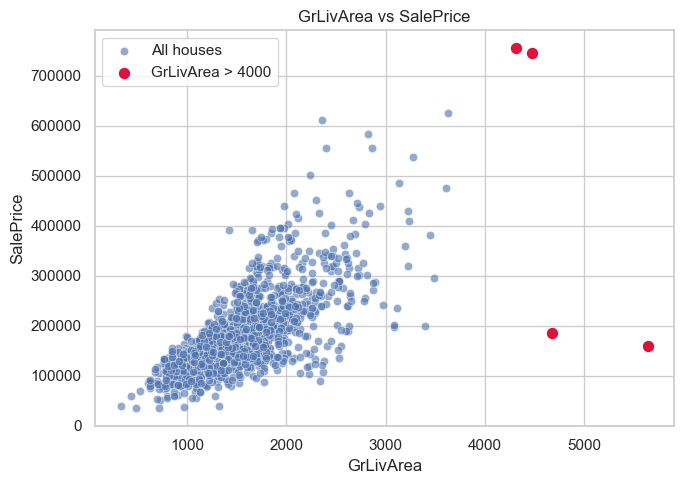

In [10]:
outliers = raw[raw['GrLivArea'] > 4000]

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=raw, x='GrLivArea', y='SalePrice', ax=ax, alpha=0.6, label='All houses')
sns.scatterplot(data=outliers, x='GrLivArea', y='SalePrice', ax=ax, color='crimson', s=80, label='GrLivArea > 4000')
ax.set_title('GrLivArea vs SalePrice')
ax.legend()
plt.tight_layout()

outliers[['Id', 'GrLivArea', 'SalePrice']]

**Reading it:** four houses have `GrLivArea` over 4000 sqft. Two of them (Ids
691 and 1183) are huge *and* expensive -- consistent with the rest of the
pattern. The other two (Ids 524 and 1299) are the famous ones: enormous houses
that sold for surprisingly little, sitting far below the main cloud of points
in the bottom-right. All four are rare enough (4 out of 1460 houses) and
unusual enough that the common practice -- which we'll follow below -- is to
exclude all four from training, not just the two that look obviously wrong.

### Refitting Model 2 without the outliers

We go back to Model 2 (`OverallQual + log(GrLivArea)`, no neighborhood or
garage yet) and refit it on the 1456 remaining houses, to see how much four
rows can move a coefficient estimated from over a thousand.

In [11]:
train_no_outliers = train[train['GrLivArea'] <= 4000]
print(f"Dropped {len(train) - len(train_no_outliers)} rows ({len(train)} -> {len(train_no_outliers)})")

model2_no_outliers = smf.ols('np.log(SalePrice) ~ OverallQual + np.log(GrLivArea)', data=train_no_outliers).fit()
print(model2_no_outliers.summary())

print(f"\nlog(GrLivArea) coefficient:  {model2.params['np.log(GrLivArea)']:.4f} (with outliers) -> {model2_no_outliers.params['np.log(GrLivArea)']:.4f} (outliers removed)")
print(f"Adjusted R-squared:          {model2.rsquared_adj:.4f} (with outliers) -> {model2_no_outliers.rsquared_adj:.4f} (outliers removed)")

Dropped 4 rows (1460 -> 1456)
                            OLS Regression Results                            
Dep. Variable:      np.log(SalePrice)   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     2306.
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:24:13   Log-Likelihood:                 323.22
No. Observations:                1456   AIC:                            -640.4
Df Residuals:                    1453   BIC:                            -624.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercep

**Reading it:** the `log(GrLivArea)` elasticity moves from **0.439 to 0.453**
-- a modest ~3% relative shift -- and adjusted R² rises from **0.751 to
0.760**. Four rows out of 1460 measurably moved a coefficient and noticeably
improved the fit; that's exactly what "high-leverage outlier" means in
practice. The shift is real but not dramatic here, which is reassuring: Model
2's earlier estimate wasn't being driven entirely by four unusual houses, just
mildly pulled by them.

## Residuals vs. fitted values, for the final model

The last diagnostic: plot Model 5's residuals (actual minus predicted
log-price) against its fitted values. This checks assumptions the coefficient
table can't show you on its own.

What "healthy" looks like: a patternless, roughly constant-width cloud of
points scattered around the horizontal zero line, with no visible shape.

What problems look like:
- **A curve** (residuals systematically positive then negative then positive
  as fitted values increase) -- the model's functional form is wrong somewhere
  (e.g. a relationship that should have been logged or given a squared term
  wasn't).
- **A fan / megaphone shape** (residuals spread out more at one end than the
  other) -- non-constant variance ("heteroskedasticity"), which is part of why
  we log the target in the first place.

Residual standard deviation (overall): 0.160

Residuals for the four GrLivArea > 4000 houses:
523    -0.770589
691     0.388938
1182    0.361426
1298   -0.903357
dtype: float64


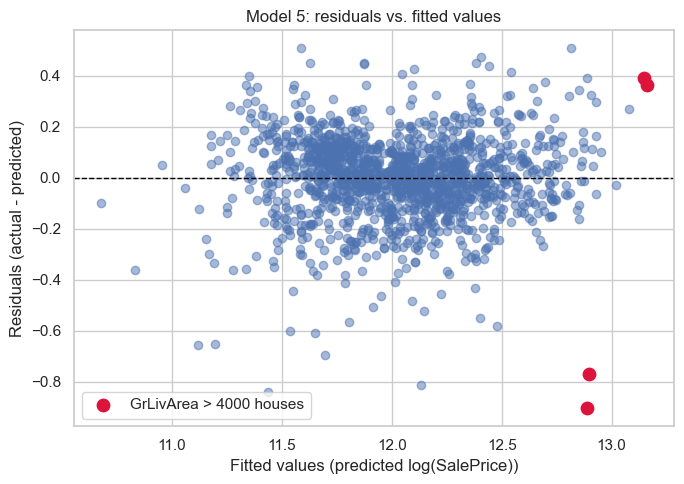

In [12]:
fitted = model5.fittedvalues
resid = model5.resid

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(fitted, resid, alpha=0.5)
ax.axhline(0, color='black', linewidth=1, linestyle='--')

outlier_rows = raw[raw['GrLivArea'] > 4000].index
ax.scatter(fitted.loc[outlier_rows], resid.loc[outlier_rows], color='crimson', s=80, label='GrLivArea > 4000 houses')

ax.set_xlabel('Fitted values (predicted log(SalePrice))')
ax.set_ylabel('Residuals (actual - predicted)')
ax.set_title('Model 5: residuals vs. fitted values')
ax.legend()
plt.tight_layout()

print(f"Residual standard deviation (overall): {resid.std():.3f}")
print("\nResiduals for the four GrLivArea > 4000 houses:")
print(resid.loc[outlier_rows])

**Reading it:** the bulk of the points form a patternless cloud centered on
zero, with no obvious curve and no obvious fan shape -- a reasonably healthy
sign for both the functional form (log-log/log-linear was a sound choice) and
the constant-variance assumption. The overall residual standard deviation is
about **0.16** (on the log scale).

The two "sold cheap" outliers (Ids 524 and 1299) stand out clearly: residuals
of about **-0.77** and **-0.90** -- roughly 5-6 residual standard deviations
below zero, far outside the main cloud. The other two large-and-expensive
houses (Ids 691 and 1183) sit at about **+0.39** and **+0.36** -- noticeably
positive, but nowhere near as extreme. This residual plot is, in effect, a
second confirmation of the same outliers the scatter plot flagged earlier,
and it's exactly why those two "sold cheap" houses are the classic candidates
for exclusion.

## Wrap-up: comparing all five models

A single table, side by side, of how many parameters each model uses and how
well each one fits -- both plain R² (which never decreases as you add
variables) and adjusted R² (which penalizes for each added parameter, and can
decrease if a variable isn't pulling its weight).

In [13]:
comparison = pd.DataFrame({
    'model': [
        '1. OverallQual',
        '2. + log(GrLivArea)',
        '3. + Neighborhood',
        '4. + GarageCars + GarageArea',
        '5. + GarageCars only (GarageArea dropped)',
    ],
    'n_params': [len(m.params) for m in [model1, model2, model3, model4, model5]],
    'r_squared': [m.rsquared for m in [model1, model2, model3, model4, model5]],
    'adj_r_squared': [m.rsquared_adj for m in [model1, model2, model3, model4, model5]],
})
comparison

,model,n_params,r_squared,adj_r_squared
0,1. OverallQual,2,0.667790,0.667563
1,2. + log(GrLivArea),3,0.751509,0.751168
2,3. + Neighborhood,27,0.827213,0.824078
3,4. + GarageCars + GarageArea,29,0.841894,0.838801
4,5. + GarageCars only (GarageArea dropped),28,0.840141,0.837127


**Reading it:** the jump from Model 3 (0.824 adjusted R²) to Model 5 (0.837,
adding just `GarageCars`) is **+0.013**. The further jump from Model 5 to
Model 4 (0.839, adding the redundant `GarageArea` *on top of* `GarageCars`) is
only **+0.002** -- a much smaller gain for a second variable that's mostly
telling the model something it already knew from the first one. Adjusted R²
is specifically built to make that visible: a variable that adds real,
independent information earns its keep; one that's redundant barely moves the
needle, or can even make adjusted R² go down if it adds noise without adding
information.

## What each rung taught

- **Model 1** gave a *clean, single coefficient* -- easy to compute, but
  reflecting a raw, uncontrolled association: quality was silently absorbing
  the effects of size and location too.
- **Model 2** introduced the **elasticity** interpretation (log-log
  coefficients are % change to % change) and showed **omitted-variable bias**
  in action -- `OverallQual`'s coefficient shrank once `GrLivArea` explained
  away part of what it had been standing in for.
- **Model 3** introduced **one-hot encoding**: one categorical column became
  24 dummy coefficients, each read *relative to a dropped baseline category*
  (here, `Blmngtn`) rather than as a standalone effect -- and showed
  `OverallQual` shrink *again*, because quality was also partly proxying for
  neighborhood.
- **Model 4** showed **multicollinearity** directly: two variables measuring
  almost the same thing (`GarageCars`, `GarageArea`, correlated at 0.88)
  produced smaller, noisier coefficients than either had alone -- confirmed
  formally by **VIF** scores near 5 for both, versus near 1-2 for the
  unrelated predictors.
- **Model 5** was **the fix** -- drop the redundant variable, and the
  surviving coefficient snaps back to a value you can trust -- while adjusted
  R² confirmed the dropped variable had barely been contributing anything
  once its correlated partner was already in the model.

Along the way, the outlier check and residual plot were a reminder that a
coefficient table is never the whole story: a handful of unusual rows can
measurably shift an estimate, and plotting residuals is how you'd notice.